# Simple PM++ example

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from matplotlib import pyplot as plt
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# os.environ["JAX_TRACEBACK_FILTERING"] = "off"

import jax
import jax.numpy as jnp
from jax.sharding import NamedSharding, PartitionSpec as P

In [3]:
try:
    os.chdir("/home/r/rouzib/links/scratch/pm")
    local = False
except:
    local = True

print(local)

True


In [4]:
pip freeze | grep jax

/bin/bash: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
jax==0.6.2
jax-cosmo==0.1.0
jax-cuda12-pjrt==0.6.2
jax-cuda12-plugin==0.6.2
jaxDecomp @ file:///mnt/c/Users/npayo/Qsync/Maitrise/Projects/PMPP/jaxDecomp
jaxlib==0.6.2
jaxtyping==0.2.34
Note: you may need to restart the kernel to use updated packages.


In [5]:
from pmwd import white_noise as white_noise_pmwd, linear_modes as linear_modes_pmwd, boltzmann, lpt as lpt_pmwd, \
    Particles as ParticlesPMWD
from pmwd import nbody as nbody_pmwd, scatter as scatter_pmwd, Configuration as ConfigurationPMWD

from src.configuration import Configuration
from src.cosmo import SimpleLCDM
from src.scatter import scatter
from src.lpt import lpt
from src.nbody import nbody
from src.particles import Particles
from src.utils import create_compute_mesh
from src.modes import linear_modes, white_noise
from src.utils import AXIS_NAME

In [6]:
box_size = 100
seed = 0

In [7]:
def init_sim(num_ptcl, mesh_shape):
    with jax.default_device(jax.devices("cpu")[0]):
        ptcl_grid_shape = (num_ptcl,) * 3
        ptcl_spacing = box_size / ptcl_grid_shape[0]
        conf = ConfigurationPMWD(ptcl_spacing, ptcl_grid_shape, mesh_shape=mesh_shape)
        cosmo = SimpleLCDM(conf)
        cosmo = boltzmann(cosmo, conf)

        modes = white_noise_pmwd(seed, conf)
        modes = linear_modes_pmwd(modes, cosmo, conf)
        ptcl_lpt, _ = lpt_pmwd(modes, cosmo, conf)

    ptcl_lpt = jax.device_put(ptcl_lpt, jax.devices()[0])
    cosmo = jax.device_put(cosmo, jax.devices()[0])
    return ptcl_lpt, conf, cosmo

In [8]:
ptcl_lpt, conf, cosmo = init_sim(128, 1)
ptcl_final, _ = nbody_pmwd(ptcl_lpt, None, cosmo, conf)

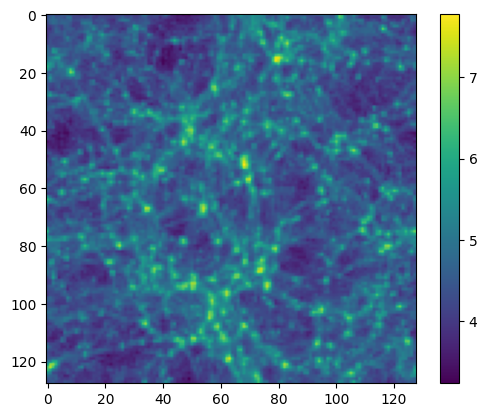

In [9]:
dens = scatter_pmwd(ptcl_final, conf)
plt.imshow(jnp.log(dens.sum(1)))
plt.colorbar()

In [10]:
%timeit -r 2 -n 2 jax.block_until_ready(nbody_pmwd(ptcl_lpt, None, cosmo, conf))

248 ms ± 1.51 ms per loop (mean ± std. dev. of 2 runs, 2 loops each)


In [ ]:
!nvidia-smi

# mGPU full sim

In [12]:
def init_mgpu(num_ptcl, mesh_shape, num_devices=None, max_ptcl_per_slice=1.2, max_share_ptcl=20000,
              max_share_gather_ptcl=50000):
    ptcl_grid_shape = (num_ptcl,) * 3
    ptcl_spacing = box_size / ptcl_grid_shape[0]

    if num_devices:
        num_devices = min(num_devices, len(jax.devices()))
    else:
        num_devices = len(jax.devices())

    compute_mesh = create_compute_mesh(jax.devices()[:num_devices])
    conf_mGPU = Configuration(ptcl_spacing, ptcl_grid_shape, mesh_shape=mesh_shape, compute_mesh=compute_mesh,
                              max_ptcl_per_slice=int(num_ptcl * num_ptcl * num_ptcl / num_devices * max_ptcl_per_slice),
                              max_share_ptcl=max_share_ptcl,
                              max_share_gather_ptcl=max_share_gather_ptcl)

    cosmo = SimpleLCDM(conf_mGPU)
    cosmo = boltzmann(cosmo, conf_mGPU)
    modes = white_noise(seed, conf_mGPU)
    modes = linear_modes(modes, cosmo, conf_mGPU)
    ptcl_lpt_mGPU = lpt(modes, cosmo, conf_mGPU)

    return ptcl_lpt_mGPU, conf_mGPU, cosmo

In [13]:
# 64, 1, 4: 1.2, 500, 8000
# 64, 5, 4: 1.2, 500, 3000
# 128, 1, 4: 1.2, 2000, 25000
# 128, 5, 4: 1.2, 2000, 10000
# 256, 1, 4: 1.2, 20000, 90000
# 256, 3, 4: 1.2, 20000, 50000
# 256, 5, 4: 1.2, 20000, 30000
# 512, 1, 4: 1.3, 100000, 400000
# 512, 2, 4: 1.3, 105000, 200000

In [14]:
nbody_jitted_mGPU = jax.jit(nbody, static_argnames=("conf", "reverse"))

In [15]:
ptcl_lpt_mGPU, conf_mGPU, cosmo = init_mgpu(128, 1, num_devices=2, max_ptcl_per_slice=1.25, max_share_ptcl=11000,
                                            max_share_gather_ptcl=30000)
ptcl_final_mGPU = nbody_jitted_mGPU(ptcl_lpt_mGPU, cosmo, conf_mGPU)

2025-10-07 16:30:40.418643: E external/xla/xla/service/slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %reduce.47 = s64[] reduce(%constant.2140, %constant.1375), dimensions={0}, to_apply=%region_22.1568, metadata={op_name="jit(lpt)/jit(main)/jit(shmap_body)/jit(add_particles)/reduce_sum" source_file="/mnt/g/Qsync/Maitrise/Projects/PM++_v2/src/particles.py" source_line=722}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2025-10-07 16:30:41.757449: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 2.338904549s
Constant folding an instruction is taking > 1s:

  %reduce.47 = s64[] reduce

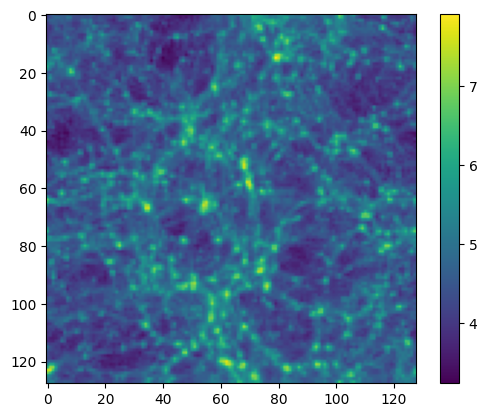

In [16]:
dens_mGPU = scatter(ptcl_final_mGPU, conf_mGPU)
plt.imshow(jnp.log(dens_mGPU.sum(1)))
plt.colorbar()

In [17]:
%timeit -r 2 -n 2 jax.block_until_ready(nbody_jitted_mGPU(ptcl_lpt_mGPU, cosmo, conf_mGPU))

1.7 s ± 61.9 ms per loop (mean ± std. dev. of 2 runs, 2 loops each)


In [ ]:
!nvidia-smi

In [19]:
print(dens_mGPU.addressable_data(index=0).shape)

(64, 128, 128)


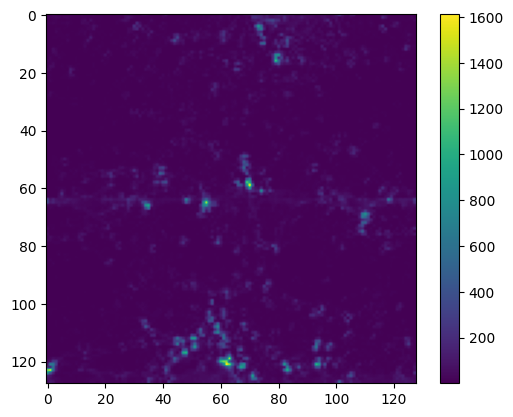

In [20]:
plt.imshow(jnp.abs(((dens - jax.device_get(dens_mGPU))).sum(1)))
plt.colorbar()